In [24]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 7.9 MB/s eta 0:00:00


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from collections import Counter

In [26]:
nltk.download('punkt')
nltk.download('punkt_tab')   # Needed for newer NLTK versions
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [27]:
df = pd.read_csv("Hotel_Reviews_Data.csv", encoding="latin1")

In [28]:
df.head()

,Review,date,Location
0,I was very impressed with the resort.\nGreat s...,20-08-2019,Sebastian
1,The rooms were nice the outside needs work als...,20-08-2019,Los Angeles
2,Great location! I have stayed at this hotel on...,20-08-2019,Georgia
3,The hotel was adequate for my stay. The strips...,20-08-2019,NaN
4,"Great location, room was large and spacious. P...",19-08-2019,Palm Harbor


In [29]:
df.columns


Index(['Review', 'date', 'Location'], dtype='object')

In [30]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6448 entries, 0 to 6447
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Review    6393 non-null   object
 1   date      6448 non-null   object
 2   Location  1711 non-null   object
dtypes: object(3)
memory usage: 151.3+ KB


In [31]:
df.isnull().sum()

,0
Review,55
date,0
Location,4737


In [32]:
reviews = df["Review"].astype(str)

df = pd.DataFrame({"Review": reviews})



In [33]:

df.head()

,Review
0,I was very impressed with the resort.\nGreat s...
1,The rooms were nice the outside needs work als...
2,Great location! I have stayed at this hotel on...
3,The hotel was adequate for my stay. The strips...
4,"Great location, room was large and spacious. P..."


In [34]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-zA-Z ]', '', text)

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

df["Cleaned_Review"] = df["Review"].apply(clean_text)

df.head()

,Review,Cleaned_Review
0,I was very impressed with the resort.\nGreat s...,impressed resortgreat staff main resort pool b...
1,The rooms were nice the outside needs work als...,room nice outside need work also free breakfas...
2,Great location! I have stayed at this hotel on...,great location stayed hotel last three trip ne...
3,The hotel was adequate for my stay. The strips...,hotel adequate stay strip bathtub useless fell...
4,"Great location, room was large and spacious. P...",great location room large spacious parking eas...


In [35]:
analyzer = SentimentIntensityAnalyzer()

def sentiment(review):

    score = analyzer.polarity_scores(review)

    compound = score['compound']

    if compound >= 0.05:
        return "Positive"

    elif compound <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Cleaned_Review"].apply(sentiment)

df.head()

,Review,Cleaned_Review,Sentiment
0,I was very impressed with the resort.\nGreat s...,impressed resortgreat staff main resort pool b...,Positive
1,The rooms were nice the outside needs work als...,room nice outside need work also free breakfas...,Positive
2,Great location! I have stayed at this hotel on...,great location stayed hotel last three trip ne...,Positive
3,The hotel was adequate for my stay. The strips...,hotel adequate stay strip bathtub useless fell...,Positive
4,"Great location, room was large and spacious. P...",great location room large spacious parking eas...,Positive


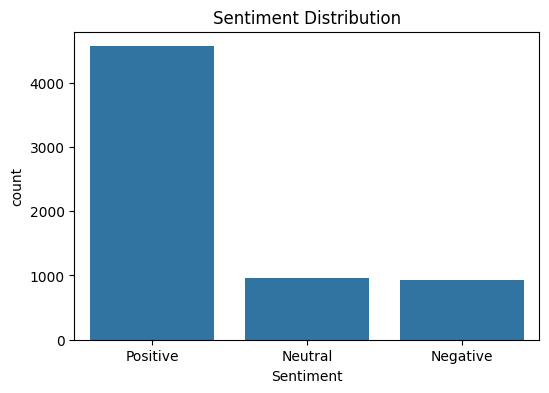

In [36]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["Sentiment"])

plt.title("Sentiment Distribution")

plt.show()

In [37]:
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df["Cleaned_Review"])

print(X.shape)

(6448, 3000)


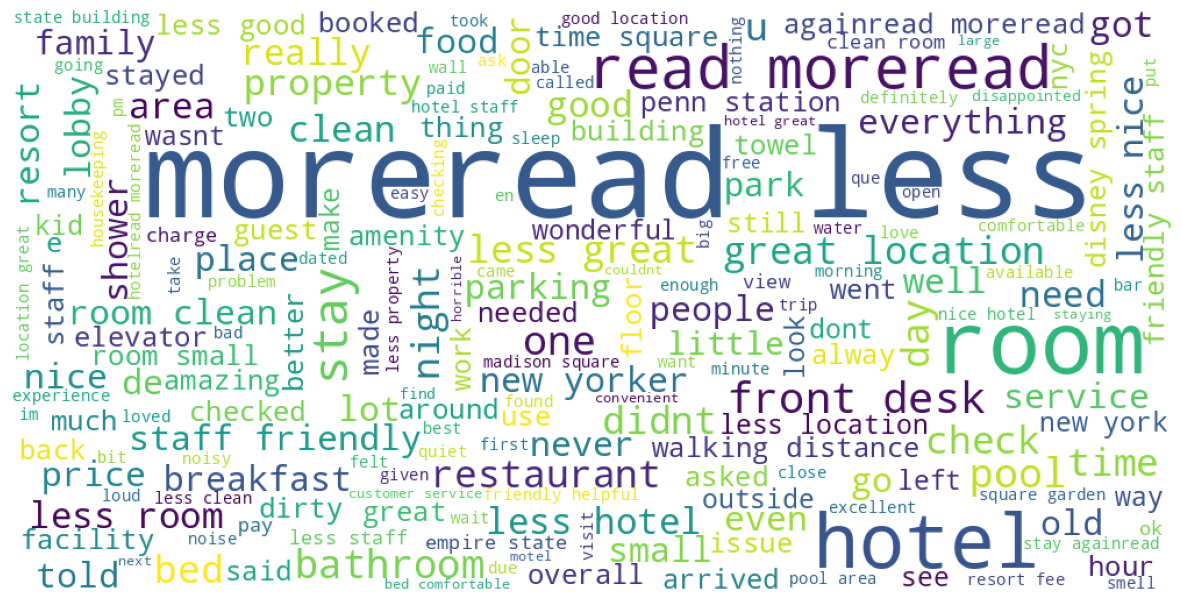

In [38]:
text = " ".join(df["Cleaned_Review"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [39]:
words = text.split()

counter = Counter(words)

top_words = counter.most_common(20)

top_words

[('less', 5358),
 ('moreread', 5311),
 ('room', 4436),
 ('hotel', 2983),
 ('staff', 1713),
 ('great', 1562),
 ('location', 1302),
 ('clean', 1265),
 ('stay', 1249),
 ('nice', 1174),
 ('read', 954),
 ('good', 924),
 ('time', 900),
 ('bed', 812),
 ('would', 749),
 ('night', 736),
 ('friendly', 734),
 ('pool', 667),
 ('service', 658),
 ('check', 619)]

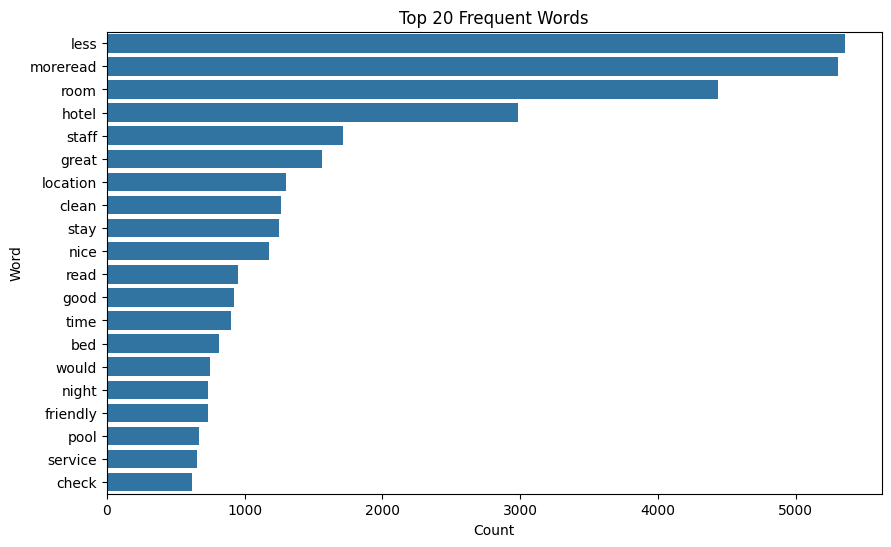

In [40]:
word_df = pd.DataFrame(top_words, columns=["Word","Count"])

plt.figure(figsize=(10,6))

sns.barplot(data=word_df,x="Count",y="Word")

plt.title("Top 20 Frequent Words")

plt.show()

In [41]:
issue_keywords = {

    "Room":["room","bed","bathroom","pillow"],

    "Staff":["staff","manager","employee","reception"],

    "Food":["food","breakfast","restaurant","dinner"],

    "Cleanliness":["dirty","clean","dust","smell"],

    "WiFi":["wifi","internet"],

    "Location":["location","distance"],

    "Parking":["parking"],

    "Pool":["pool"],

    "Gym":["gym"]

}

In [42]:
def detect_issue(review):

    found=[]

    for issue,keywords in issue_keywords.items():

        for word in keywords:

            if word in review:

                found.append(issue)

                break

    if len(found)==0:

        found.append("Other")

    return ", ".join(found)

df["Issues"] = df["Cleaned_Review"].apply(detect_issue)

df.head()

,Review,Cleaned_Review,Sentiment,Issues
0,I was very impressed with the resort.\nGreat s...,impressed resortgreat staff main resort pool b...,Positive,"Staff, Cleanliness, Location, Pool"
1,The rooms were nice the outside needs work als...,room nice outside need work also free breakfas...,Positive,"Room, Food"
2,Great location! I have stayed at this hotel on...,great location stayed hotel last three trip ne...,Positive,Location
3,The hotel was adequate for my stay. The strips...,hotel adequate stay strip bathtub useless fell...,Positive,"Staff, Food"
4,"Great location, room was large and spacious. P...",great location room large spacious parking eas...,Positive,"Room, Staff, Location, Parking"


In [43]:
issue_count = df["Issues"].value_counts()

issue_count

,count
Issues,
Other,1410
Room,772
"Room, Cleanliness",461
Staff,284
Location,281
...,...
"Room, Staff, Food, Cleanliness, WiFi, Pool",1
"Staff, Food, Cleanliness, Pool",1
"Location, Gym",1


In [45]:
total = len(df)

positive = len(df[df["Sentiment"]=="Positive"])

negative = len(df[df["Sentiment"]=="Negative"])

neutral = len(df[df["Sentiment"]=="Neutral"])

print("------------ HOTEL REPORT ------------")

print("Total Reviews :", total)

print("Positive Reviews :", positive)

print("Negative Reviews :", negative)

print("Neutral Reviews :", neutral)

print()

print("Customer Satisfaction Score")

print(round((positive/total)*100,2),"%")

------------ HOTEL REPORT ------------
Total Reviews : 6448
Positive Reviews : 4562
Negative Reviews : 931
Neutral Reviews : 955

Customer Satisfaction Score
70.75 %


In [46]:
df[df["Sentiment"]=="Negative"][["Review","Issues"]].head(10)

,Review,Issues
31,Les chambres familiales sont pratiques (nous ...,Other
32,Rooms very dirty and aged. Breakfast was of po...,"Room, Food, Cleanliness"
46,This property is advertised as being renovated...,"Room, Staff"
56,"The rooms are terribly small, almost claustrop...",Room
57,They made us pay for gym facilities we didn?t ...,Gym
63,I liked everything except the smoking by the p...,"Cleanliness, Pool"
65,The pool was nice but the staff was rude and w...,"Room, Staff, Cleanliness, Pool"
84,nos encanto tanto el trato recibido en la rece...,Other
86,Didn?t like being charged for parking and reso...,Parking
92,"This is a pleasant hotel, I was a little disap...","Food, Pool"


In [47]:
df[df["Sentiment"]=="Positive"][["Review","Issues"]].head(10)

,Review,Issues
0,I was very impressed with the resort.\nGreat s...,"Staff, Cleanliness, Location, Pool"
1,The rooms were nice the outside needs work als...,"Room, Food"
2,Great location! I have stayed at this hotel on...,Location
3,The hotel was adequate for my stay. The strips...,"Staff, Food"
4,"Great location, room was large and spacious. P...","Room, Staff, Location, Parking"
5,All the options for fun were great! Do wish th...,Other
7,Loved the layout of the hotel and the relaxing...,"Room, Staff, Pool"
8,My wife and I loved everything about it. It?s ...,Other
9,"rooms were very small, was told i had a compli...",Room
10,Very clean and friendly and I love the locatio...,"Room, Food, Cleanliness, Location"


In [48]:
df.to_csv("Hotel_Review_Analysis_Output.csv", index=False)

print("Report Saved Successfully!")

Report Saved Successfully!


In [49]:
test_review = "The hotel room was clean, spacious, and the staff were very friendly."

score = analyzer.polarity_scores(test_review)

print(score)

{'neg': 0.0, 'neu': 0.618, 'pos': 0.382, 'compound': 0.7346}


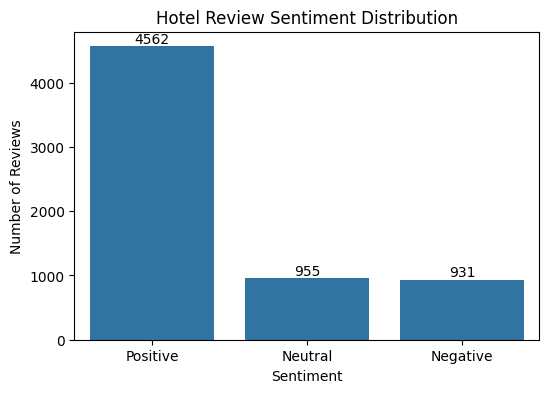

In [52]:


plt.figure(figsize=(6,4))

ax = sns.countplot(
    x="Sentiment",
    data=df,
    order=["Positive", "Neutral", "Negative"]
)

plt.title("Hotel Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

for container in ax.containers:
    ax.bar_label(container)

plt.show()